In [3]:
import os
import sys

# 1. Clone the specific branch of the repository
repo_url = "https://github.com/allarom/advanced-genai-26.git"
repo_dir = "advanced-genai-26"
branch_name = "dongy"

if not os.path.exists(repo_dir):
    !git clone -b {branch_name} {repo_url}

# 2. Add the repo to the system path so imports work correctly
if repo_dir not in sys.path:
    sys.path.append(os.path.abspath(repo_dir))

# 3. Copy the notebook to the current directory so %run finds it
!cp {repo_dir}/multi-agent-step-2_strategy-A.ipynb .

print("✅ Project environment synchronized.")
!ls

Cloning into 'advanced-genai-26'...
remote: Enumerating objects: 232, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 232 (delta 16), reused 26 (delta 9), pack-reused 198 (from 1)
Receiving objects: 100% (232/232), 5.66 MiB | 13.44 MiB/s, done.
Resolving deltas: 100% (111/111), done.
✅ Project environment synchronized.
 advanced-genai-26		       sample_data
 multi-agent-step-2_strategy-A.ipynb  'Screenshot 2026-05-29 at 19.07.49.png'


g# Reliable and Adaptive Agentic RAG System (Step 3)

This notebook extends the Step 2 multi-agent retrieval system with reliability, adaptation, recovery, and trust mechanisms.

The goal is to make the RAG system more reliable when evidence is:

weak
incomplete
ambiguous
contradictory

The notebook implements multiple reliability mechanisms and adaptive orchestration behaviors.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
import os
print(f'Current working directory: {os.getcwd()}')
!ls -a

Current working directory: /content
 .   ..   .config   sample_data  'Screenshot 2026-05-29 at 19.07.49.png'


In [5]:
# Re-running this check to verify the current state after the git clone
import os
files = os.listdir('.')
if 'multi-agent-step-2_strategy-A.ipynb' in files:
    print('✅ Step 2 notebook found! The environment is now correctly set up.')
else:
    print('❌ Step 2 notebook NOT found. Please ensure cell 7ee9b477 ran successfully.')

✅ Step 2 notebook found! The environment is now correctly set up.


## 1. Installation

In [6]:
# Fix for the pytrec_eval build error and other dependencies
# Update package lists and install system dependencies for pytrec_eval
!apt-get update
!apt-get install -y libtrec-dev
!pip install -q pandas numpy transformers accelerate pytrec_eval

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package libtrec-dev


## 2. Imports

In [7]:
import re
import time
import random
import numpy as np
import pandas as pd

from collections import defaultdict

## 3. Load Step 2 Components

This section imports the orchestration strategies and retrievers
from the Step 2 notebook implementation.

Setup complete.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT = /content/drive/MyDrive/Adv_GenAI
EVAL_SCOPE = full_corpus
All required retrieval artifacts found.
BM25 loaded: <class '__main__.BilingualBM25'> -> adapter ready


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Dense retriever ready.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

,method,queries_evaluated,MRR,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5,Precision@10,Recall@10
0,Voting (C),24,0.34375,0.25,0.02322,0.166667,0.025342,0.15,0.028979,0.116667,0.031985



=== Strategy C — Efficiency Summary ===


,0
queries_total,24.000000
avg_latency_s,0.261147
p95_latency_s,0.303842
retry_count,0.000000



=== Strategy C — Retrieval Health Check ===
retrieval_errors: none
zero_result_retrievers: none
Query: Who at ETH received ERC grants?
Strategy A (Weighted) Top 5 IDs: ['455c5e6fa03aaf70b745bcec98f92048a0fdd3d1_fixed_0', '327dfd590409db9eb6c600a5e3b71792d37d8075_fixed_1', 'b391e9189684d3b2a19d0da5edf7de0f3e5d7cfa_fixed_0', '327dfd590409db9eb6c600a5e3b71792d37d8075_fixed_0', 'ed0534de840e4c5ae5d00dd32841df0f3aea131f_fixed_0']
Strategy C (Voting) Top 5 IDs:   ['455c5e6fa03aaf70b745bcec98f92048a0fdd3d1_fixed_0', '327dfd590409db9eb6c600a5e3b71792d37d8075_fixed_1', 'b391e9189684d3b2a19d0da5edf7de0f3e5d7cfa_fixed_0', '327dfd590409db9eb6c600a5e3b71792d37d8075_fixed_0', 'ed0534de840e4c5ae5d00dd32841df0f3aea131f_fixed_0']

Overlap in Top 5: 5/5
Equal weighting 'democratizes' the result set, often bringing back docs
that were suppressed by the heavy Graph/Dense weights in Strategy A.
--- Statistical Comparison: Strategy A vs Strategy C ---
Mean MRR (Confidence A): 0.3646
Mean MRR (Voting C):   

,method,queries_evaluated,MRR,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5,Precision@10,Recall@10
0,Confidence (A),24,0.364583,0.291667,0.023399,0.152778,0.025065,0.141667,0.029486,0.112500,0.033084
1,Waterfall (B),24,0.254630,0.208333,0.002477,0.111111,0.003359,0.116667,0.004512,0.087500,0.006581
2,Voting (C),24,0.343750,0.250000,0.023220,0.166667,0.025342,0.150000,0.028979,0.116667,0.031985


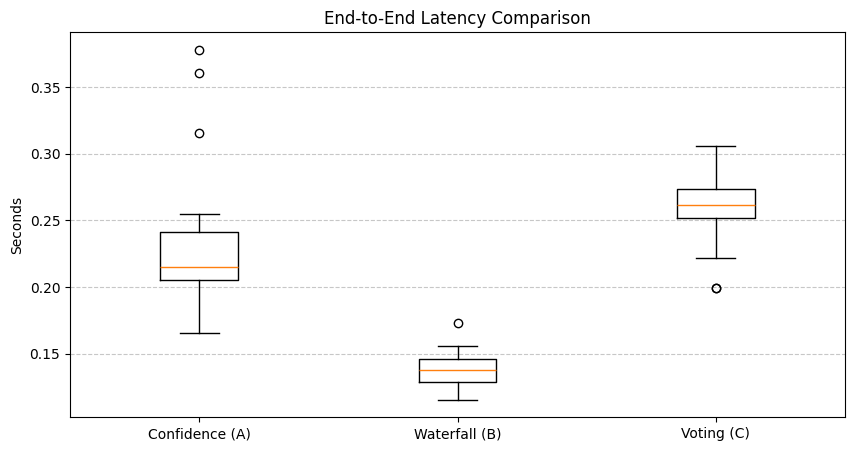


=== Strategy Efficiency Comparison ===


,method,queries_total,avg_latency_s,p95_latency_s,retry_count,avg_tiers_run,critic_fail_count
0,Confidence (A),24,0.232242,0.353820,0,NaN,NaN
1,Waterfall (B),24,0.138708,0.155885,0,1.0,0.0
2,Voting (C),24,0.261147,0.303842,0,NaN,NaN


Saved Strategy A/B/C artifacts to /content/drive/MyDrive/Adv_GenAI/results/strategy_comparison_full_corpus

=== Paired t-tests on per-query MRR ===
Confidence (A) vs Waterfall (B): t=1.451, p=0.160
Confidence (A) vs Voting (C): t=0.577, p=0.570
Waterfall (B) vs Voting (C): t=-1.352, p=0.190
=== 2.1 Baseline Evaluation (Full Corpus) — report structure ===


,method,queries_evaluated,MRR,Precision@1,Recall@1,Precision@3,Recall@3,Precision@5,Recall@5,Precision@10,Recall@10
0,GraphRAG,24,0.232573,0.083333,0.000687,0.097222,0.003166,0.116667,0.005892,0.116667,0.052857
1,ReRank,24,0.222952,0.041667,0.000196,0.138889,0.004480,0.125000,0.006323,0.100000,0.010619
2,Hybrid,24,0.202154,0.000000,0.000000,0.097222,0.003699,0.125000,0.028352,0.095833,0.031149
3,Dense,24,0.165525,0.041667,0.000147,0.069444,0.008953,0.058333,0.010095,0.066667,0.034097
4,BM25,24,0.151296,0.041667,0.001016,0.055556,0.001681,0.091667,0.005506,0.091667,0.011165



=== 2.2 Orchestration Evaluation (full_corpus) — report structure ===


...


=== 2.3 Baseline Subsample vs Full Corpus Comparison — report structure ===


,Scope,Method,MRR,P@1,P@3,P@5,P@10,R@1,R@3,R@5,R@10
0,full_corpus,BM25,0.151296,0.041667,0.055556,0.091667,0.091667,0.001016,0.001681,0.005506,0.011165
1,subsample,BM25,0.396272,0.166667,0.305556,0.316667,0.295833,0.002081,0.010785,0.017426,0.037034
2,full_corpus,Dense,0.165525,0.041667,0.069444,0.058333,0.066667,0.000147,0.008953,0.010095,0.034097
3,subsample,Dense,0.540476,0.375000,0.402778,0.350000,0.304167,0.031450,0.064326,0.073926,0.093394
4,full_corpus,GraphRAG,0.232573,0.083333,0.097222,0.116667,0.116667,0.000687,0.003166,0.005892,0.052857
5,subsample,GraphRAG,0.579613,0.458333,0.444444,0.366667,0.337500,0.029346,0.059344,0.063712,0.080849
6,full_corpus,Hybrid,0.202154,0.000000,0.097222,0.125000,0.095833,0.000000,0.003699,0.028352,0.031149
7,subsample,Hybrid,0.462108,0.250000,0.347222,0.316667,0.316667,0.004266,0.062629,0.076968,0.097059
8,full_corpus,ReRank,0.222952,0.041667,0.138889,0.125000,0.100000,0.000196,0.004480,0.006323,0.010619
9,subsample,ReRank,0.442001,0.291667,0.250000,0.233333,0.245833,0.002821,0.006986,0.012018,0.029840



=== Notebook Orchestration Scope Comparison ===


,Scope,Method,MRR,P@1,P@3,P@5,P@10,R@1,R@3,R@5,R@10
0,full_corpus,Confidence,0.364583,0.291667,0.152778,0.141667,0.112500,0.023399,0.025065,0.029486,0.033084
1,full_corpus,Waterfall,0.254630,0.208333,0.111111,0.116667,0.087500,0.002477,0.003359,0.004512,0.006581
2,full_corpus,Voting,0.343750,0.250000,0.166667,0.150000,0.116667,0.023220,0.025342,0.028979,0.031985


Note: orchestration full-vs-subsample comparison needs both saved runs.
Run this notebook once with EVAL_SCOPE='full_corpus' and once with EVAL_SCOPE='subsample' to populate both rows.

Saved report-aligned tables to /content/drive/MyDrive/Adv_GenAI/results/report_aligned_strategy_comparison_full_corpus
Step 2 orchestrators loaded. Wrappers ready.


In [9]:
%run multi-agent-step-2_strategy-A.ipynb

# --- Wrapper functions for Step 3 compatibility ---
# The legacy notebook defines orchestrator CLASSES with .run() methods.
# Step 3 expects FUNCTIONS that return (docs, trace).
# These wrappers bridge the two interfaces.

def confidence_orchestrate(query, top_k=5):
    """Run ConfidenceOrchestrator and return (answer, docs, trace)."""
    answer, docs, trace = orchestrator.run(query, top_k=top_k)
    return answer, docs, trace

def waterfall_orchestrate(query, top_k=5):
    """Run WaterfallOrchestrator and return (answer, docs, trace)."""
    answer, docs, trace = waterfall_orchestrator.run(query, top_k=top_k)
    return answer, docs, trace

def voting_orchestrate(query, top_k=5):
    """Run VotingOrchestrator (equal weights) and return (answer, docs, trace)."""
    answer, docs, trace = voting_orchestrator.run(query, top_k=top_k)
    return answer, docs, trace

print('Step 2 orchestrators loaded. Wrappers ready.')


In [14]:
# Inspect the lengths of the retrieved chunks (documents)
print(f"Number of documents retrieved: {len(docs)}")
for i, d in enumerate(docs[:5]):
    content = d.page_content
    char_count = len(content)
    word_count = len(content.split())
    print(f"Doc {i} length: {char_count} characters (~{word_count} words)")
    print(f"Snippet: {content[:100]}...")
    print("-" * 30)

Number of documents retrieved: 10
Doc 0 length: 1887 characters (~277 words)
Snippet: passage: these eth students are competing in the olympics: - several athletes with a connection to e...
------------------------------
Doc 1 length: 1785 characters (~173 words)
Snippet: passage: 2014 retrospective: , eth was right in the thick of the action at the [winter olympics](/en...
------------------------------
Doc 2 length: 543 characters (~103 words)
Snippet: a good year for the pv eth in 2014 retir member associ pv eth the retir member associ pv eth was fou...
------------------------------
Doc 3 length: 2063 characters (~351 words)
Snippet: eth zurich at wef 2017 intern exchang the eth deleg is also use the world econom forum 2017 as an op...
------------------------------
Doc 4 length: 1462 characters (~232 words)
Snippet: following in eschers footsteps: winners this year", summed up ralph eichler, former eth president an...
------------------------------


## 4. Utility Functions

In [11]:
def normalize(text):
    """Cleans text and converts it into a set of unique lowercase words."""
    # Convert to lowercase to ensure case-insensitive matching
    text = text.lower()
    # Remove punctuation using regex, replacing it with spaces
    text = re.sub(r"[^\w\s]", " ", text)
    # Split into words and return a set for fast overlap calculation
    return set(text.split())

def overlap_score(a, b):
    """Calculates the percentage of words in 'a' that are also found in 'b'."""
    # Normalize both strings into sets of tokens
    ta = normalize(a)
    tb = normalize(b)

    # Prevent division by zero if string 'a' is empty
    if len(ta) == 0:
        return 0.0

    # Intersection (ta & tb) finds common words; divide by total in 'a'
    return len(ta & tb) / len(ta)

## 5. Mechanisms

### 5.1 Evidence Sufficiency Estimation (A)
This module estimates whether the retrieved evidence is sufficient.

Signals used:

- overlap between query and retrieved chunks
- number of supporting chunks
- retrieval fusion score

In [12]:
class EvidenceSufficiencyAgent:
    """
    Checks: Do we have enough evidence to answer this question?

    How it works:
    - Count how many query words appear in each retrieved document.
    - Calculate average overlap across top 5 docs.
    - If average >= 0.15, evidence is considered sufficient.

    Why it matters:
    Prevents the system from answering when retrieval returns
    irrelevant or off-topic documents.
    """

    def assess(self, query, docs):

        if len(docs) == 0:
            return {
                "sufficient": False,
                "score": 0.0,
            }

        q_tokens = normalize(query)

        support_scores = []

        for d in docs[:5]:

            txt = d.page_content
            d_tokens = normalize(txt)

            overlap = len(q_tokens & d_tokens)
            overlap = overlap / max(len(q_tokens), 1)

            support_scores.append(overlap)

        avg_support = np.mean(support_scores)

        sufficient = avg_support >= 0.15

        return {
            "sufficient": sufficient,
            "score": round(float(avg_support), 3),
            "supporting_chunks": len([
                x for x in support_scores if x > 0.1
            ])
        }


### %.2 Groundness / Support Verification (B)
The answer is verified against retrieved evidence.

In [15]:
class GroundednessAgent:
    """
    Checks: Is the answer actually supported by the retrieved documents?

    How it works (dual-threshold):
    1. Global check: answer words must overlap >= 45% with ALL docs combined
    (more than 45% words appear in all docs).
       (ensures the answer is broadly supported across evidence)
    2. Per-doc check: at least ONE doc must share >= 25% of answer words.
       (ensures the answer is strongly supported by at least one source)
       'Share' means that a single document must contain enough of the answer's key vocabulary
    Both thresholds must pass. Stopwords (the, is, of...) are ignored.

    Why it matters:
    Prevents hallucination — answers that sound plausible but are not
    actually found in the source documents.
    """

    # Lightweight stopword list for cleaner token overlap
    _STOP = {
        'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
        'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
        'shall', 'should', 'can', 'could', 'may', 'might', 'must',
        'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from', 'as', 'to',
        'and', 'or', 'but', 'if', 'then', 'than', 'so', 'yet',
        'it', 'its', 'this', 'that', 'these', 'those',
        'i', 'you', 'he', 'she', 'we', 'they', 'me', 'him', 'her',
        'us', 'them', 'my', 'your', 'his', 'our', 'their',
        'what', 'which', 'who', 'when', 'where', 'why', 'how',
    }

    def _tokens(self, text):
        """Return set of non-stopword tokens."""
        return normalize(text) - self._STOP

    def verify(self, answer, docs,
               min_global_overlap=0.45,
               min_per_doc_overlap=0.25):

        ans_tokens = self._tokens(answer)

        if len(ans_tokens) == 0:
            return False

        # --- global overlap: answer vs union of all docs ---
        all_doc_tokens = set()
        per_doc_overlaps = []

        for d in docs[:5]:
            txt = d.page_content or ''
            doc_tokens = self._tokens(txt)
            all_doc_tokens |= doc_tokens
            per_doc = len(ans_tokens & doc_tokens) / max(len(ans_tokens), 1)
            per_doc_overlaps.append(per_doc)

        global_overlap = len(ans_tokens & all_doc_tokens) / max(len(ans_tokens), 1)
        best_doc_overlap = max(per_doc_overlaps) if per_doc_overlaps else 0.0

        grounded = (
            global_overlap >= min_global_overlap and
            best_doc_overlap >= min_per_doc_overlap
        )

        return grounded



### 5.3 Contradiction Detection (C)
This mechanism checks whether retrieved chunks contain conflicting statements.

Lightweight heuristic:

- detect conflicting keywords
- detect opposite numeric claims

In [16]:
import re

class ContradictionAgent:
    """
    Checks: Do the retrieved documents contradict each other?

    How it works (two heuristics):
    1. Antonym keywords (word-boundary matched, so 'no' does NOT match
       'Nobel' or 'north'). Pairs like increase/decrease, true/false.
    2. Year conflict: if focused documents (each mentioning exactly one
       year) cite DIFFERENT years, the sources disagree on 'when'.

    Why it matters:
    Conflicting evidence produces unreliable answers. We lower trust so
    the system can recover or abstain instead of guessing.
    Future upgrade: LLM-based semantic contradiction detection.
    """

    CONTRADICTIONS = [
        ("yes", "no"),
        ("increase", "decrease"),
        ("increased", "decreased"),
        ("rose", "fell"),
        ("higher", "lower"),
        ("true", "false"),
        ("approved", "rejected"),
    ]

    def _has_word(self, word, text):
        # \\b = word boundary, so we match whole words only.
        return re.search(r"\b" + re.escape(word) + r"\b", text) is not None

    def _single_year(self, text):
        years = re.findall(r"\b(?:1\d{3}|20\d{2})\b", text)
        return years[0] if len(set(years)) == 1 and years else None

    def detect(self, docs):

        texts = [d.page_content.lower() for d in docs[:5]]

        # Heuristic 1: antonym keyword conflict (whole-word match)
        for a, b in self.CONTRADICTIONS:

            has_a = any(self._has_word(a, t) for t in texts)
            has_b = any(self._has_word(b, t) for t in texts)

            if has_a and has_b:
                return {
                    "contradiction": True,
                    "reason": f"Detected conflict: {a} vs {b}"
                }

        # Heuristic 2: focused docs disagree on the year
        single_years = [y for y in (self._single_year(t) for t in texts) if y]

        if len(set(single_years)) > 1:
            return {
                "contradiction": True,
                "reason": f"Date conflict across sources: {sorted(set(single_years))}"
            }

        return {
            "contradiction": False,
            "reason": "No obvious contradiction detected"
        }

### 5.4 Clarification Strategy (D)
The system detects ambiguous or underspecified questions.

In [17]:
class ClarificationAgent:
    """
    Checks: Is the user's question clear enough to answer?

    How it works:
    - Too short? (<= 3 words) → likely underspecified.
    - Contains vague pronouns? ('it', 'they', 'this') → ambiguous reference.
    If either rule matches, ask the user to clarify.

    Why it matters:
    Prevents the system from guessing when the user's intent is unclear.
    Better to ask than to answer the wrong question.
    """

    def needs_clarification(self, query):

        q = query.lower().strip()

        ambiguous = [
            "it",
            "they",
            "this",
            "that",
        ]

        short_query = len(q.split()) <= 3

        ambiguous_ref = any(x in q.split() for x in ambiguous)

        if short_query or ambiguous_ref:
            return True

        return False

    def clarification_question(self, query):

        return (
            "Could you clarify your question or provide "
            "more specific details?"
        )


### 5.5 Abstention Mechanism (E)
The system abstains when evidence is weak or contradictory.

In [18]:
class AbstentionAgent:
    """
    Decides: Should the system refuse to answer?

    How it works (Step 2 §2.3):
    Abstains when the overall TRUST score falls below a threshold (0.4).
    The trust score already combines evidence sufficiency, groundedness,
    and contradiction, so a single threshold captures every failure mode:
    - low sufficiency  -> low trust
    - not grounded     -> low trust
    - contradiction    -> low trust

    Why it matters:
    A system that knows when it does NOT know is more trustworthy than one
    that always guesses. This is the 'I don't know' safety net, and using
    the trust score keeps the decision consistent with the trace signals.
    """

    def should_abstain(self, trust, threshold=0.4):

        return trust["score"] < threshold

### 5.6 Self-Reflection / Critique Loop (F)
The critic reviews the draft answer.

In [22]:
import re

class CriticAgent:
    """
    Reviews the draft answer and reports any quality issues.

    Checks performed:
    1. Grounding: flags if answer is weakly supported by documents.
    2. Contradiction: flags if evidence conflicts.
    3. Length: flags if answer is suspiciously short (< 3 words).
    4. Temporal coherence (entity_temporal queries only):
       - Finds all years mentioned in the answer.
       - Checks if at least one year is within +/- 10 of the query year.
       - Catches answers that reference the wrong decade entirely.

    Why it matters:
    The Critic is the final quality gate before the answer reaches the user.
    It catches subtle errors that other agents might miss.
    """

    _YEAR_RE = re.compile(r'\b(1\d{3}|20\d{2})\b')

    def _temporal_coherent(self, answer, query_year, window=10):
        """
        Answer must mention at least one year within +/- window of query_year.
        Catches answers that are grounded but reference the wrong decade.
        """
        found = [int(m) for m in self._YEAR_RE.findall(answer)]
        return any(abs(y - query_year) <= window for y in found)

    def critique(self,
                 answer,
                 grounded,
                 contradiction,
                 query_type=None,
                 query_year=None):

        feedback = []

        if not grounded:
            feedback.append("Answer weakly supported")

        if contradiction["contradiction"]:
            feedback.append("Evidence conflict detected")

        if len(answer.split()) < 3:
            feedback.append("Answer too short")

        # Temporal coherence check for entity_temporal queries
        if query_type == 'entity_temporal' and query_year:
            temporal_ok = self._temporal_coherent(answer, query_year, window=10)
            if not temporal_ok:
                feedback.append(
                    f"Temporal mismatch: answer references wrong time period (expected around {query_year})"
                )

        if len(feedback) == 0:
            feedback.append("Answer appears acceptable")

        return feedback

### 5.7 Recovery Mechanism (G)
The system changes behavior dynamically.

Recovery actions:

- switch retrieval strategy
- rewrite query
- move to clarification mode
- abstain

In [21]:
class RecoveryAgent:
    """
    Decides HOW to fix a low-reliability result, and the orchestrator
    executes that action (re-retrieve). This is the 'adaptive' part.

    Action priority (checks the WHY behind low trust):
    1. contradiction  -> switch_strategy to 'voting' (cross-checks sources)
    2. not grounded   -> switch_strategy to 'waterfall' (escalates retrievers
                         BM25 -> +Dense -> +Graph to broaden evidence)
    3. not sufficient -> rewrite_query (add context to improve retrieval)
    4. otherwise      -> none

    Note: groundedness is now considered (it was ignored before). Switching
    to 'waterfall' is the Step-3-layer equivalent of the old CriticAgent's
    'broaden retrieval' retry, since retriever weights live inside the
    orchestrator and cannot be tuned directly from here.

    Why it matters:
    Instead of giving up, the system tries to fix the problem once before
    abstaining. This turns 'reliable' into 'reliable AND adaptive'.
    """

    def rewrite_query(self, query):

        return query + " ETH Zurich"

    def recover(self,
                query,
                current_strategy,
                sufficiency,
                contradiction,
                grounded=True):

        if contradiction["contradiction"]:

            return {
                "action": "switch_strategy",
                "new_strategy": "voting"
            }

        if not grounded:

            fallback = "waterfall" if current_strategy != "waterfall" else "voting"

            return {
                "action": "switch_strategy",
                "new_strategy": fallback
            }

        if not sufficiency["sufficient"]:

            rewritten = self.rewrite_query(query)

            return {
                "action": "rewrite_query",
                "query": rewritten
            }

        return {
            "action": "none"
        }

### 5.8 Trust / Confidence Scoring (H)
The confidence score combines:

- evidence sufficiency
- groundedness
- contradiction detection

In [23]:
class TrustAgent:
    """
    Computes a single confidence score from all reliability signals.

    Formula:
    trust = 0.6 * sufficiency_score + 0.3 * groundedness_bonus - 0.4 * contradiction_penalty

    Score ranges:
    - HIGH (> 0.7): strong evidence, confident answer.
    - MEDIUM (0.4-0.7): acceptable but not perfect.
    - LOW (< 0.4): weak evidence, consider abstaining.

    Why it matters:
    Turns multiple checks into one easy-to-understand number.
    Users and downstream systems can act on this single score.
    """

    def score(self,
              sufficiency,
              grounded,
              contradiction):

        score = 0.0

        score += sufficiency["score"] * 0.6

        if grounded:
            score += 0.3

        if contradiction["contradiction"]:
            score -= 0.4

        score = max(0.0, min(1.0, score))

        if score > 0.7:
            label = "HIGH"
        elif score > 0.4:
            label = "MEDIUM"
        else:
            label = "LOW"

        return {
            "score": round(float(score), 3),
            "label": label
        }


## 6. Adaptive Reliable RAG Orchestrator
This orchestrator integrates all reliability mechanisms.

In [24]:
class ReliableAdaptiveRAG:
    """
    Main orchestrator: wraps the Step 2 retrieval engine with
    8 reliability agents to produce trustworthy answers.

    Decision flow (4 branches):
    1. CLARIFY → if query is ambiguous (short / pronouns)
    2. ABSTAIN → if evidence is weak, ungrounded, or contradictory
    3. RECOVER → if first attempt fails, retry with new strategy/query
    4. ANSWER → if all checks pass, return the synthesized answer

    Returns a unified trace dict matching Step 2 §2.4:
    {decision, reason, signals, intermediate, final_answer, trace_log}
    """

    def __init__(self, ablate=None):
        self.ablate = set(ablate or [])

        self.sufficiency = EvidenceSufficiencyAgent()
        self.groundedness = GroundednessAgent()
        self.contradiction = ContradictionAgent()
        self.clarification = ClarificationAgent()
        self.abstention = AbstentionAgent()
        self.critic = CriticAgent()
        self.recovery = RecoveryAgent()
        self.trust = TrustAgent()

        self._draft_answer = None
        self._last_strategy = None

    def retrieve(self, query, strategy="confidence", top_k=5):
        if strategy == "waterfall":
            answer, docs, trace = waterfall_orchestrate(query, top_k)
        elif strategy == "voting":
            answer, docs, trace = voting_orchestrate(query, top_k)
        else:
            answer, docs, trace = confidence_orchestrate(query, top_k)

        self._draft_answer = answer
        self._last_strategy = strategy
        return docs, trace

    def generate_answer(self, docs):
        if len(docs) == 0:
            return "NOT FOUND"

        # Use orchestrator's synthesized answer if available
        if self._draft_answer and len(self._draft_answer.strip()) > 5:
            return self._draft_answer

        # Fallback: truncate first doc (legacy placeholder)
        return docs[0].page_content[:250]

    _YEAR_RE = re.compile(r'\b(1\d{3}|20\d{2})\b')

    def _extract_year(self, query):
        """Simple year extractor for temporal coherence checks."""
        m = self._YEAR_RE.search(query)
        return int(m.group()) if m else None

    def _ablated(self, agent_name):
        return agent_name in self.ablate

    def _compute_signals(self, query, docs, answer, ablated, query_type=None):
        """Run all reliability agents and return signals dict."""
        trace_log = []

        suff = self.sufficiency.assess(query, docs)
        trace_log.append(f"Sufficiency: {suff['sufficient']} (score={suff['score']})")

        if not "groundedness" in ablated:
            grounded = self.groundedness.verify(answer, docs)
            trace_log.append(f"Groundedness: {grounded}")
        else:
            grounded = True
            trace_log.append("Groundedness: ABATED")

        if not "contradiction" in ablated:
            contradiction = self.contradiction.detect(docs)
            trace_log.append(f"Contradiction: {contradiction['contradiction']}")
        else:
            contradiction = {"contradiction": False}
            trace_log.append("Contradiction: ABATED")

        trust = self.trust.score(suff, grounded, contradiction)
        trace_log.append(f"Trust: {trust['score']} ({trust['label']})")

        if not "critic" in ablated:
            critique = self.critic.critique(
                answer, grounded, contradiction,
                query_type=query_type, query_year=self._extract_year(query),
            )
            trace_log.append(f"Critique: {len(critique)} issues")
        else:
            critique = []
            trace_log.append("Critique: ABATED")

        abstain = self.abstention.should_abstain(trust)

        signals = {
            "evidence_sufficiency": round(float(suff["score"]), 3),
            "grounding_score": 1.0 if grounded else 0.0,
            "has_contradictions": contradiction["contradiction"],
            "query_ambiguous": self.clarification.needs_clarification(query),
            "trust_score": trust["score"],
        }

        return {
            "suff": suff,
            "grounded": grounded,
            "contradiction": contradiction,
            "trust": trust,
            "critique": critique,
            "abstain": abstain,
            "signals": signals,
            "trace_log": trace_log,
        }

    def run(self,
            query,
            strategy="confidence",
            ablate=None,
            query_type=None,
            query_year=None):

        ablated = set(ablate or []) | self.ablate
        trace_log = []
        retry_count = 0
        recovery_action = None
        strategy_used = strategy

        # --- Clarification branch ---
        if self.clarification.needs_clarification(query):
            trace_log.append("Clarification triggered")
            return {
                "decision": "clarify",
                "reason": "Query is ambiguous (short or contains pronouns)",
                "signals": {
                    "evidence_sufficiency": 0.0,
                    "grounding_score": 0.0,
                    "has_contradictions": False,
                    "query_ambiguous": True,
                    "trust_score": 0.0,
                },
                "intermediate": {
                    "strategy_used": strategy,
                    "recovery_action": None,
                    "retry_count": 0,
                },
                "final_answer": None,
                "trace_log": trace_log,
            }

        # --- First retrieval pass ---
        docs, retrieval_trace = self.retrieve(query, strategy)
        trace_log.extend(retrieval_trace)
        answer = self.generate_answer(docs)

        result = self._compute_signals(query, docs, answer, ablated, query_type)
        trace_log.extend(result["trace_log"])

        # --- Recovery branch: try to RESCUE before abstaining ---
        # Recovery now runs WHEN the system would abstain (low reliability),
        # giving the pipeline a chance to fix the problem before giving up.
        if result["abstain"] and not "recovery" in ablated:
            recovery = self.recovery.recover(
                query, strategy, result["suff"], result["contradiction"],
                result["grounded"]
            )
            recovery_action = recovery["action"]
            trace_log.append(f"Low reliability -> recovery action: {recovery_action}")

            if recovery_action == "switch_strategy":
                new_strategy = recovery["new_strategy"]
                trace_log.append(f"RETRY: switching to {new_strategy}")
                docs, retrieval_trace = self.retrieve(query, new_strategy)
                trace_log.extend(retrieval_trace)
                answer = self.generate_answer(docs)
                result = self._compute_signals(query, docs, answer, ablated, query_type)
                trace_log.extend(result["trace_log"])
                retry_count = 1
                strategy_used = new_strategy

            elif recovery_action == "rewrite_query":
                rewritten = recovery["query"]
                trace_log.append(f"RETRY: rewritten query -> {rewritten}")
                docs, retrieval_trace = self.retrieve(rewritten, strategy)
                trace_log.extend(retrieval_trace)
                answer = self.generate_answer(docs)
                result = self._compute_signals(query, docs, answer, ablated, query_type)
                trace_log.extend(result["trace_log"])
                retry_count = 1

        # --- Abstention branch (runs after any recovery attempt) ---
        if result["abstain"]:
            if retry_count > 0:
                abstain_reason = "Recovery attempted but evidence still unreliable"
            else:
                abstain_reason = "Evidence insufficient, ungrounded, or contradictory"
            trace_log.append("System abstained")
            return {
                "decision": "abstain",
                "reason": abstain_reason,
                "signals": result["signals"],
                "intermediate": {
                    "strategy_used": strategy_used,
                    "recovery_action": recovery_action,
                    "retry_count": retry_count,
                },
                "final_answer": None,
                "trace_log": trace_log,
            }

        # --- Answer branch ---
        if retry_count > 0:
            answer_reason = "Recovery succeeded; all reliability checks passed"
        else:
            answer_reason = "All reliability checks passed"
        trace_log.append("Answer generated successfully")
        return {
            "decision": "answer",
            "reason": answer_reason,
            "signals": result["signals"],
            "intermediate": {
                "strategy_used": strategy_used,
                "recovery_action": recovery_action,
                "retry_count": retry_count,
            },
            "final_answer": answer,
            "trace_log": trace_log,
        }



## 7. Initialize System

In [26]:
rag_system = ReliableAdaptiveRAG()

## 8. Example Queries
This section demonstrates:

- clarification behavior
- abstention
- recovery
- contradiction handling
- successful answer generation

In [27]:


queries = [
    "Who received ERC grants at ETH?",
    "How does ETH support innovation?",
    "it",
    "What research areas are important at ETH Zurich?"
]

for q in queries:

    print("\n" + "=" * 80)
    print("QUERY:", q)

    result = rag_system.run(q)

    print("\nDECISION:", result["decision"])
    print("REASON:", result["reason"])
    print("ANSWER:", result["final_answer"] or "(none)")

    print("\nSIGNALS:")
    for k, v in result["signals"].items():
        print(f"  {k}: {v}")

    print("\nINTERMEDIATE:")
    for k, v in result["intermediate"].items():
        print(f"  {k}: {v}")

    print("\nTRACE:")
    for t in result["trace_log"]:
        print("-", t)


QUERY: Who received ERC grants at ETH?

DECISION: abstain
REASON: Recovery attempted but evidence still unreliable
ANSWER: (none)

SIGNALS:
  evidence_sufficiency: 0.6
  grounding_score: 1.0
  has_contradictions: True
  query_ambiguous: False
  trust_score: 0.26

INTERMEDIATE:
  strategy_used: voting
  recovery_action: switch_strategy
  retry_count: 1

TRACE:
- query
- query_type
- weights
- retry_weights
- gated_out
- retriever_counts
- retrieval_errors
- zero_result_retrievers
- retry_triggered
- critic_ok
- critic_feedback
- evidence_ids
- latency_s
- bilingual_variants
- Sufficiency: True (score=0.6)
- Groundedness: True
- Contradiction: True
- Trust: 0.26 (LOW)
- Critique: 1 issues
- Low reliability -> recovery action: switch_strategy
- RETRY: switching to voting
- query
- query_type
- weights
- retry_weights
- gated_out
- retriever_counts
- retrieval_errors
- zero_result_retrievers
- retry_triggered
- critic_ok
- critic_feedback
- evidence_ids
- latency_s
- bilingual_variants
- 

## 9. Benchmark Evaluation
This section evaluates:

- reliability scores
- latency
- system behavior
- abstention frequency

In [32]:
results = []

# Try eval_qa_data first (loaded from strategy-A notebook),
# fallback to qa_data if available.
_qa_data = eval_qa_data if "eval_qa_data" in globals() else (qa_data if "qa_data" in globals() else [])

# Removed the 20-question cap to evaluate the full dataset
N = len(_qa_data)

print(f"Starting benchmark for all {N} questions...")

for i in range(N):
    q = _qa_data[i]["question"]

    start = time.time()
    result = rag_system.run(q)
    runtime = time.time() - start

    trust_score = result["signals"]["trust_score"]

    results.append({
        "query": q,
        "decision": result["decision"],
        "trust": trust_score,
        "runtime": runtime,
        "strategy": result["intermediate"]["strategy_used"],
        "retry_count": result["intermediate"]["retry_count"],
    })

benchmark_df = pd.DataFrame(results)
display(benchmark_df.head())

Starting benchmark for all 24 questions...


,query,decision,trust,runtime,strategy,retry_count
0,who were the rectors of eth between 2017 and 2...,answer,0.624,0.254361,confidence,0
1,who at eth received erc grants?,abstain,0.240,0.532985,voting,1
2,when did the insight get to mars?,abstain,0.243,0.411503,voting,1
3,what did prof. schubert say about flying?,abstain,0.106,0.389002,voting,1
4,what is e-sling?,clarify,0.000,0.000009,confidence,0


## 9a. Export Audit CSV

Run the cell below to export every query's full reliability data to a **timestamped CSV file**.

This creates an audit trail so you can:
- Compare runs after changing thresholds or agents
- Share results with teammates without screenshots
- Roll back to a known-good configuration

Filename format: `YYYY-MM-DD_HH-MM-SS_output_step3.csv`


In [ ]:
# --- CSV Export for Audit Trail ---
# Run this after the benchmark cell to save all reliability data to a timestamped CSV.

import csv, time, os
from datetime import datetime

audit_rows = []

# Re-run benchmark with FULL signal extraction + error handling
_qa_data = eval_qa_data if "eval_qa_data" in globals() else (qa_data if "qa_data" in globals() else [])

print(f"Exporting {len(_qa_data)} queries to CSV...")

run_timestamp = datetime.now().isoformat()

for i, item in enumerate(_qa_data):
    q = item["question"]
    start = time.time()

    try:
        result = rag_system.run(q)
        runtime = time.time() - start
    except Exception as e:
        print(f"Query {i} crashed: {q[:50]}... | Error: {e}")
        runtime = time.time() - start
        result = {
            "decision": "error",
            "reason": str(e),
            "signals": {},
            "intermediate": {},
            "final_answer": None,
            "trace_log": [f"ERROR: {e}"],
        }

    sig = result.get("signals", {})
    inter = result.get("intermediate", {})

    row = {
        "query": q,
        "decision": result.get("decision", ""),
        "reason": result.get("reason", ""),
        "final_answer": result.get("final_answer") or "",
        "trust_score": sig.get("trust_score", 0.0),
        "evidence_sufficiency": sig.get("evidence_sufficiency", 0.0),
        "grounding_score": sig.get("grounding_score", 0.0),
        "has_contradictions": sig.get("has_contradictions", False),
        "query_ambiguous": sig.get("query_ambiguous", False),
        "strategy_used": inter.get("strategy_used", ""),
        "recovery_action": inter.get("recovery_action", ""),
        "retry_count": inter.get("retry_count", 0),
        "runtime_sec": round(runtime, 4),
        "run_timestamp": run_timestamp,
        "trace_summary": " | ".join(result.get("trace_log", [])[:5]),
    }
    audit_rows.append(row)

# Build filename with timestamp
ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
filename = f"{ts}_output_step3.csv"
filepath = f"/content/{filename}" if os.path.exists("/content") else filename

# Write CSV
if audit_rows:
    with open(filepath, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=audit_rows[0].keys())
        writer.writeheader()
        writer.writerows(audit_rows)
    print(f"Saved {len(audit_rows)} rows to: {filepath}")
    print("")
    print("Preview:")
    display(pd.DataFrame(audit_rows).head())
else:
    print("No rows to export.")


## 10. Aggregate Statistics


In [29]:
benchmark_df.groupby("decision")[["trust", "runtime"]].mean()


,trust,runtime
decision,,
abstain,0.187714,0.500017
answer,0.617000,0.314058
clarify,0.000000,0.000020


In [30]:
benchmark_df["decision"].value_counts()


,count
decision,
answer,10
abstain,7
clarify,3


## 11. Failure Analysis

This section examines low-confidence cases.

In [31]:
low_conf = benchmark_df[
    benchmark_df["trust"] < 0.4
]

low_conf

,query,decision,trust,runtime,strategy,retry_count
1,who at eth received erc grants?,abstain,0.240,0.477704,voting,1
2,when did the insight get to mars?,abstain,0.243,0.509608,voting,1
3,what did prof. schubert say about flying?,abstain,0.106,0.493230,voting,1
4,what is e-sling?,clarify,0.000,0.000013,confidence,0
7,how do alpine plants respond to climate change?,abstain,0.320,0.557139,voting,1
8,how would you make ferzlizer without carbon em...,abstain,0.000,0.507705,voting,1
9,what research is eth famous for?,abstain,0.280,0.548156,voting,1
10,how much of eth’s electricity consumpzon is du...,clarify,0.000,0.000029,confidence,0
12,who is working on methods for targeted cancer ...,clarify,0.000,0.000017,confidence,0
16,what conneczons does eth have to hong kong?,abstain,0.125,0.406581,voting,1


## 12. Final Discussion

This notebook implemented a reliable and adaptive agentic RAG framework aligned with the official Step 3 requirements.

Implemented capabilities:

- evidence sufficiency estimation
- groundedness verification
- contradiction detection
- clarification handling
- abstention
- self-reflection
- adaptive recovery
- trust estimation

The system dynamically adapts its behavior when failures or uncertainty are detected.

Limitations:

- heuristic-based reliability estimation
- lightweight contradiction detection
- simple answer generation

Future improvements:

- stronger verifier models
- semantic contradiction detection
- reinforcement learning orchestration
- retrieval strategy optimization
- claim-level grounding verification